---
## Cell 1 — Imports & Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
sns.set_palette('Set2')

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


---
## Cell 2 — Load Both Datasets


In [2]:
# ── Load datasets ──────────────────────────────────────────────────────────────
df_real = pd.read_csv('Project-Data\survey_responses_real-data.csv')
df_auto = pd.read_csv('Project-Data\survey_responses_auto_generated_data.csv')

print('Raw shapes:')
print(f'  Real data    : {df_real.shape[0]} rows × {df_real.shape[1]} columns')
print(f'  Synthetic    : {df_auto.shape[0]} rows × {df_auto.shape[1]} columns')

# Real data comes from Google Form so column names are full question text
rename_map = {
    '1. Year of Study: (1st / 2nd / 3rd / 4th)'                                        : 'Year of Study',
    '2. Gender: (Male / Female)'                                                         : 'Gender',
    '3. Age: (ex: 20 / 21 /22)'                                                          : 'Age',
    '4. CGPA: (ex : 4.00 / 3.75 /3.50)                     [Optional]'                  : 'CGPA',
    '5. How many hours do you spend on studying per week? ([Numeric] ex: 5 / 4.5 / 10)' : 'Weekly study hours',
    '6. How many courses are you currently enrolled in? \n([Numeric] ex: 2 / 3 / 4)'    : 'Number of courses',
    '7. Do you participate in extracurricular activities? (Yes/No)'                       : 'Extracurricular (Yes/No)',
    '8. If yes, how many hours per week?  ([Numeric] ex: 5 / 4.5 / 10)'                 : 'Extracurricular hours',
    '9. Do you have a part-time job? (Yes/No)'                                           : 'Part-time job (Yes/No)',
    '10. If yes, how many hours per week?  ([Numeric] ex: 5 / 4.5 / 10)'                : 'Part-time hours',
    '11. On a scale of 1\u20135, how would you rate your stress level this semester? (1 = Very Low, 5 = Very High)' : 'Stress level',
    '12. On a scale of 1\u20135, how would you rate your anxiety level? (1 = No anxiety, 5 = Extreme anxiety)'     : 'Anxiety score',
    '13. On average, how many hours of sleep do you get per night?  ( ex : 7/8/9  )'    : 'Sleep hours',
    '14. On a scale of 1\u201310, how would you rate your overall sleep quality?'        : 'Sleep quality',
}

# Drop metadata columns (Timestamp, Username) from real data
df_real = df_real.drop(columns=['Timestamp', 'Username']).rename(columns=rename_map)

# Tag source
df_real['DataType'] = 'Real'
df_auto['DataType'] = 'Synthetic'

# Combine
df = pd.concat([df_real, df_auto], ignore_index=True)
print(f'\nCombined (before cleaning): {df.shape[0]} rows × {df.shape[1]} columns')
df.head(5)

Raw shapes:
  Real data    : 55 rows × 16 columns
  Synthetic    : 150 rows × 14 columns

Combined (before cleaning): 205 rows × 15 columns


,Year of Study,Gender,Age,CGPA,Weekly study hours,Number of courses,Extracurricular (Yes/No),Extracurricular hours,Part-time job (Yes/No),Part-time hours,Stress level,Anxiety score,Sleep hours,Sleep quality,DataType
0,2nd,Female,21,NaN,4.5,3,Yes,4/5 hours,Yes,Almost 20hours,4.0,4.0,7,5.0,Real
1,1st,Female,22,NaN,5,2,Yes,7,Yes,7,1.0,1.0,7,2.0,Real
2,3rd,Female,23,2.75,4,8,Yes,16,Yes,16,5.0,5.0,4/5,4.0,Real
3,3rd,Female,22,NaN,2-3 hr,3,Yes,12-13 hr,Yes,10hr,3.0,3.0,6 hr,6.0,Real
4,3rd,Female,23,NaN,5,3,No,NaN,No,NaN,3.0,5.0,7,7.0,Real


---
## Cell 3 — Data Cleaning


In [3]:
# ── Helper: Clean messy numeric strings ───────────────────────────────────────
# Handles: '7-8' → 7.5, '4/5 hours' → 4.5, '10hr' → 10, 'Almost 20hours' → 20
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    s = re.sub(r'[a-zA-Z]+', '', s)   # strip letters/units
    s = s.strip()
    # Range values like '7-8' or '4/5' → take average
    for sep in ['-', '/']:
        if sep in s:
            parts = s.split(sep)
            try:
                return np.mean([float(p.strip()) for p in parts if p.strip() != ''])
            except:
                pass
    try:
        return float(s)
    except:
        return np.nan

# ── Helper: Clean Year of Study ───────────────────────────────────────────────
# Handles: '1st', '2nd ', '4rth', 'Graduated', '4tg', '5th' (invalid → NaN)
def clean_year(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if 'grad' in s:          # 'Graduated' / 'Graduate' → treat as 4th year
        return 4
    m = re.search(r'(\d)', s)
    if m:
        yr = int(m.group(1))
        return yr if 1 <= yr <= 4 else np.nan   # 5th year → NaN (invalid)
    return np.nan

# ── Apply numeric cleaning to all numeric-intended columns ─────────────────────
numeric_cols = ['Extracurricular hours', 'Part-time hours', 'Sleep hours',
                'Weekly study hours', 'Number of courses',
                'Age', 'CGPA', 'Sleep quality', 'Stress level', 'Anxiety score']
for c in numeric_cols:
    df[c] = df[c].apply(clean_numeric)

# ── Clean Year of Study ────────────────────────────────────────────────────────
df['Year of Study'] = df['Year of Study'].apply(clean_year)

# ── Encode categorical columns ─────────────────────────────────────────────────
df['Gender']                    = df['Gender'].astype(str).str.strip().map({'Male': 1, 'Female': 0})
df['Extracurricular (Yes/No)'] = df['Extracurricular (Yes/No)'].map({'Yes': 1, 'No': 0})
df['Part-time job (Yes/No)']   = df['Part-time job (Yes/No)'].map({'Yes': 1, 'No': 0})

# ── Fill NaN (median for numeric, mode for remaining object) ──────────────────
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# ── Clip to valid ranges ──────────────────────────────────────────────────────
df['Stress level']  = df['Stress level'].clip(1, 5)
df['Anxiety score'] = df['Anxiety score'].clip(1, 5)
df['Sleep quality'] = df['Sleep quality'].clip(1, 10)
df['Year of Study'] = df['Year of Study'].clip(1, 4).astype(int)

# ── Drop exact duplicates (only once) ─────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')
df.reset_index(drop=True, inplace=True)

print(f'\n✅ Final dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'   Real: {(df["DataType"]=="Real").sum()}  |  Synthetic: {(df["DataType"]=="Synthetic").sum()}')
print(f'   Missing values: {df.isnull().sum().sum()}')

print('\nEncoding Summary:')
print('  Year of Study            → integer 1–4')
print('  Gender                   → 1=Male, 0=Female')
print('  Extracurricular (Yes/No) → 1=Yes, 0=No')
print('  Part-time job  (Yes/No)  → 1=Yes, 0=No')
df.head()

Duplicates removed: 0

✅ Final dataset: 205 rows × 15 columns
   Real: 55  |  Synthetic: 150
   Missing values: 0

Encoding Summary:
  Year of Study            → integer 1–4
  Gender                   → 1=Male, 0=Female
  Extracurricular (Yes/No) → 1=Yes, 0=No
  Part-time job  (Yes/No)  → 1=Yes, 0=No


,Year of Study,Gender,Age,CGPA,Weekly study hours,Number of courses,Extracurricular (Yes/No),Extracurricular hours,Part-time job (Yes/No),Part-time hours,Stress level,Anxiety score,Sleep hours,Sleep quality,DataType
0,2,0,21.0,3.32,4.5,3.0,1,4.5,1,20.0,4.0,4.0,7.0,5.0,Real
1,1,0,22.0,3.32,5.0,2.0,1,7.0,1,7.0,1.0,1.0,7.0,2.0,Real
2,3,0,23.0,2.75,4.0,8.0,1,16.0,1,16.0,5.0,5.0,4.5,4.0,Real
3,3,0,22.0,3.32,2.5,3.0,1,12.5,1,10.0,3.0,3.0,6.0,6.0,Real
4,3,0,23.0,3.32,5.0,3.0,0,6.0,0,9.0,3.0,5.0,7.0,7.0,Real


---
## Cell 4 — Missing Value Check

In [4]:
print('Missing Values After Cleaning:')
mv = df.isnull().sum()
print(mv[mv > 0] if mv.sum() > 0 else '  No missing values ✓')

print('\nData Types:')
print(df.dtypes)

Missing Values After Cleaning:
  No missing values ✓

Data Types:
Year of Study                 int64
Gender                        int64
Age                         float64
CGPA                        float64
Weekly study hours          float64
Number of courses           float64
Extracurricular (Yes/No)      int64
Extracurricular hours       float64
Part-time job (Yes/No)        int64
Part-time hours             float64
Stress level                float64
Anxiety score               float64
Sleep hours                 float64
Sleep quality               float64
DataType                     object
dtype: object


---
## Cell 5 — Summary Statistics

In [5]:
KEY = ['Weekly study hours', 'Number of courses', 'Extracurricular hours',
       'Part-time hours', 'Stress level', 'Anxiety score',
       'Sleep hours', 'Sleep quality', 'Age', 'CGPA']

desc = df[KEY].describe().T
desc['variance'] = df[KEY].var()
desc['skewness'] = df[KEY].skew()
desc['kurtosis'] = df[KEY].kurtosis()

print('Summary Statistics for Key Variables (n =', len(df), ')')
print('=' * 95)
print(desc[['mean', '50%', 'std', 'variance', 'min', 'max', 'skewness', 'kurtosis']]
      .rename(columns={'50%': 'median'})
      .round(3).to_string())

Summary Statistics for Key Variables (n = 205 )
                         mean  median     std  variance   min   max  skewness  kurtosis
Weekly study hours     17.976   17.00  11.306   127.835  0.00  39.0     0.247    -1.208
Number of courses       4.229    4.00   1.197     1.432  0.00   8.0     0.449     0.605
Extracurricular hours   6.539    6.00   4.031    16.248  0.00  16.0     0.322    -0.735
Part-time hours         9.954    9.00   6.747    45.528  0.00  42.0     1.171     3.208
Stress level            3.449    3.00   1.194     1.425  1.00   5.0    -0.279    -0.866
Anxiety score           3.420    3.00   0.960     0.921  1.00   5.0    -0.020    -0.538
Sleep hours             6.376    6.40   1.370     1.878  2.50   9.7    -0.153    -0.164
Sleep quality           6.015    6.00   1.916     3.671  1.00  10.0    -0.139     0.044
Age                    21.234   21.00   2.442     5.965  2.00  27.0    -2.355    17.529
CGPA                    3.283    3.32   0.420     0.176  2.29   4.0    -

---
## Cell 6 — Demographics Bar Charts



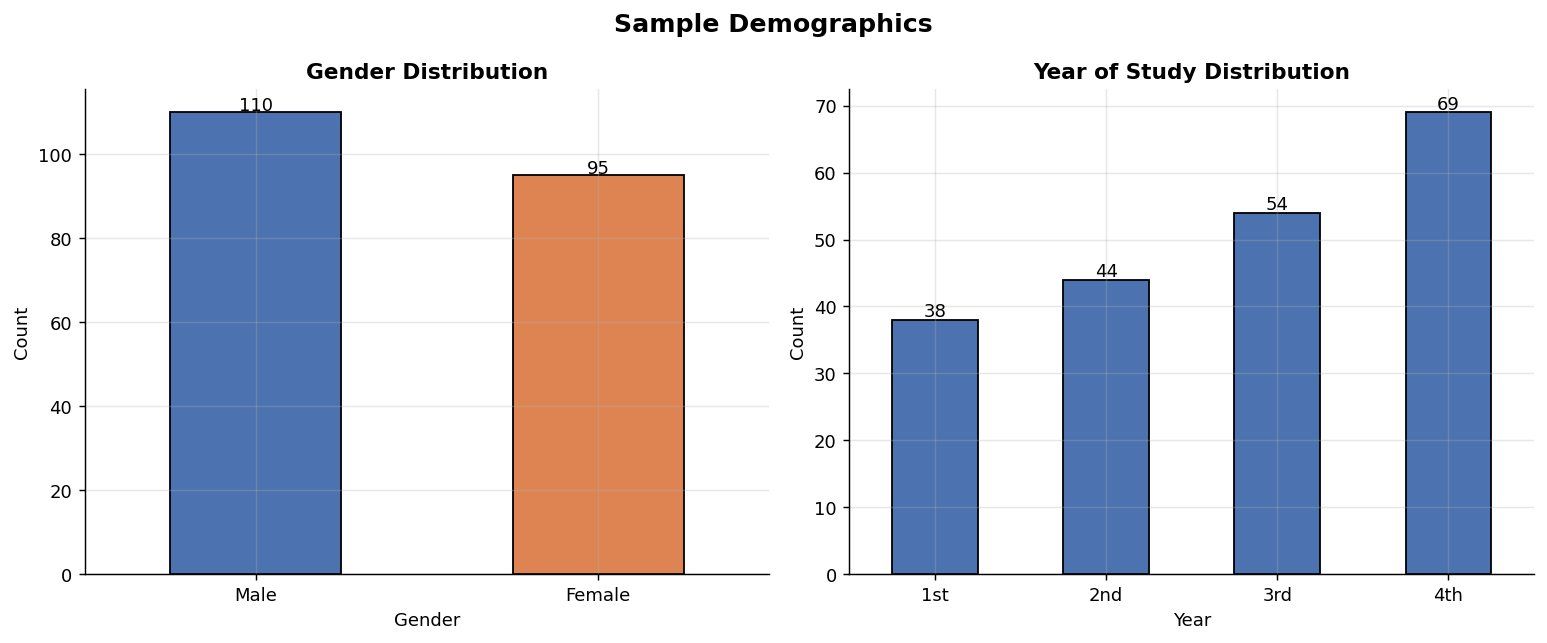

Figure 1 — Sample demographics


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Sample Demographics', fontsize=14, fontweight='bold')

# Gender (encoded as 0/1 — map back to labels for readability)
gender_labels = df['Gender'].map({1: 'Male', 0: 'Female'})
gender_counts = gender_labels.value_counts()
gender_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Gender Distribution', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5), ha='center')

# FIX 5: Year of Study is now integer 1–4, reindex on integers
year_counts = df['Year of Study'].value_counts().reindex([1, 2, 3, 4], fill_value=0)
year_counts.index = ['1st', '2nd', '3rd', '4th']   # rename for display
year_counts.plot(kind='bar', ax=axes[1], color='#4C72B0', edgecolor='black')
axes[1].set_title('Year of Study Distribution', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5), ha='center')

plt.tight_layout()
plt.savefig('Figures\demographics.png', bbox_inches='tight')
plt.show()
print('Figure 1 — Sample demographics')

---
## Cell 7 — Distributions of Key Variables

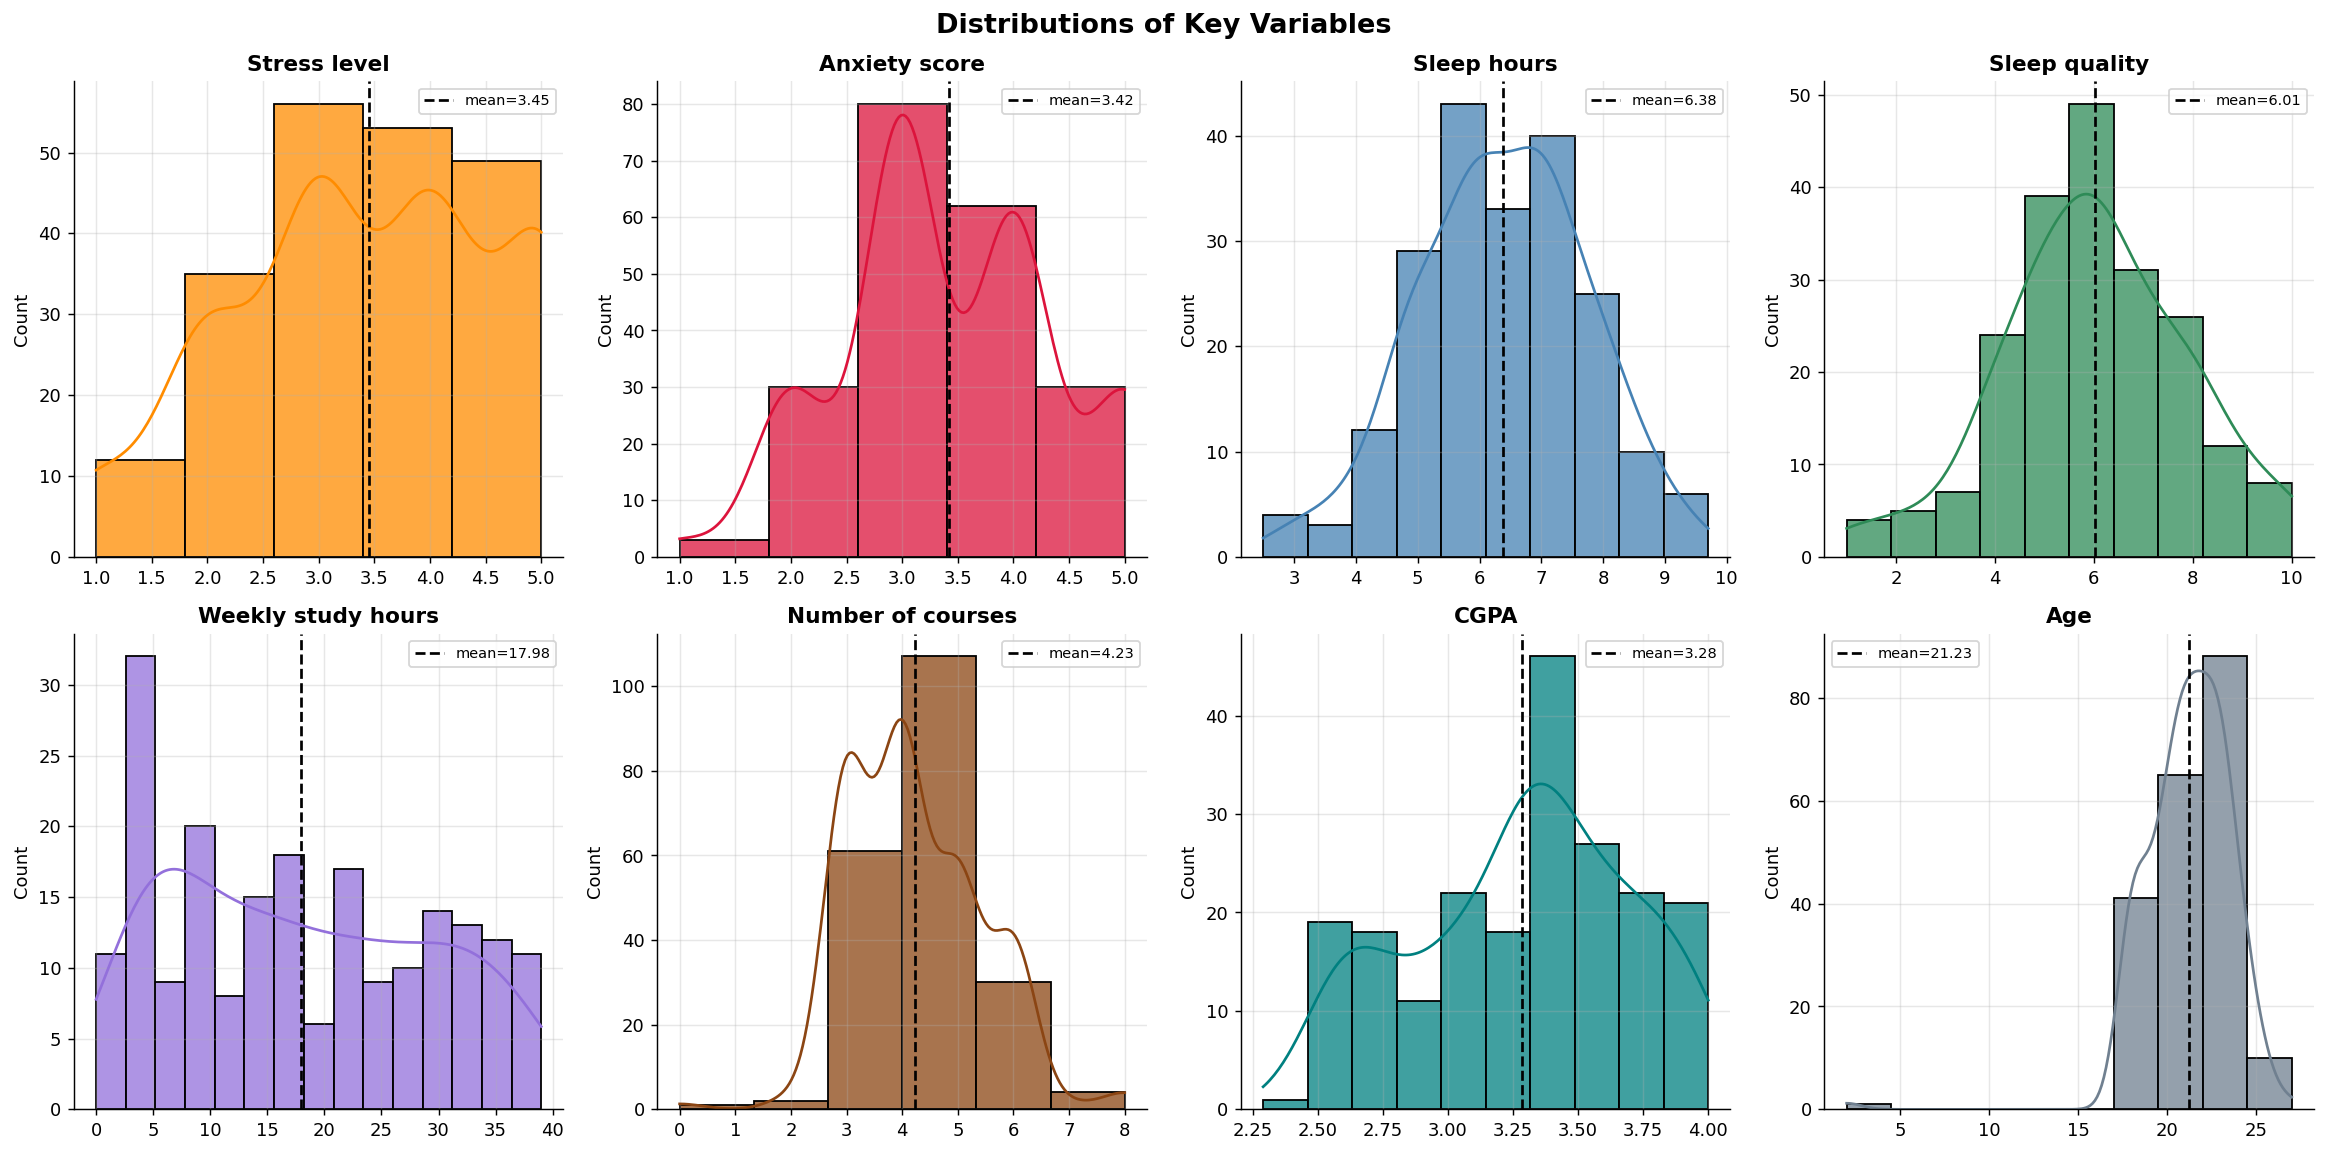

Figure 2 — Histograms with KDE curves. Dashed lines = sample mean.


In [7]:
specs = [
    ('Stress level',       'darkorange',   5),
    ('Anxiety score',      'crimson',      5),
    ('Sleep hours',        'steelblue',   10),
    ('Sleep quality',      'seagreen',    10),
    ('Weekly study hours', 'mediumpurple', 15),
    ('Number of courses',  'saddlebrown',  6),
    ('CGPA',               'teal',        10),
    ('Age',                'slategray',   10),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distributions of Key Variables', fontsize=15, fontweight='bold')
for ax, (v, col, b) in zip(axes.flatten(), specs):
    sns.histplot(df[v], kde=True, bins=b, color=col, ax=ax, alpha=0.75)
    ax.axvline(df[v].mean(), color='black', ls='--', lw=1.5, label=f'mean={df[v].mean():.2f}')
    ax.set_title(v, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('Figures\distributions.png', bbox_inches='tight')
plt.show()
print('Figure 2 — Histograms with KDE curves. Dashed lines = sample mean.')

---
## Cell 8 — Boxplots by Gender



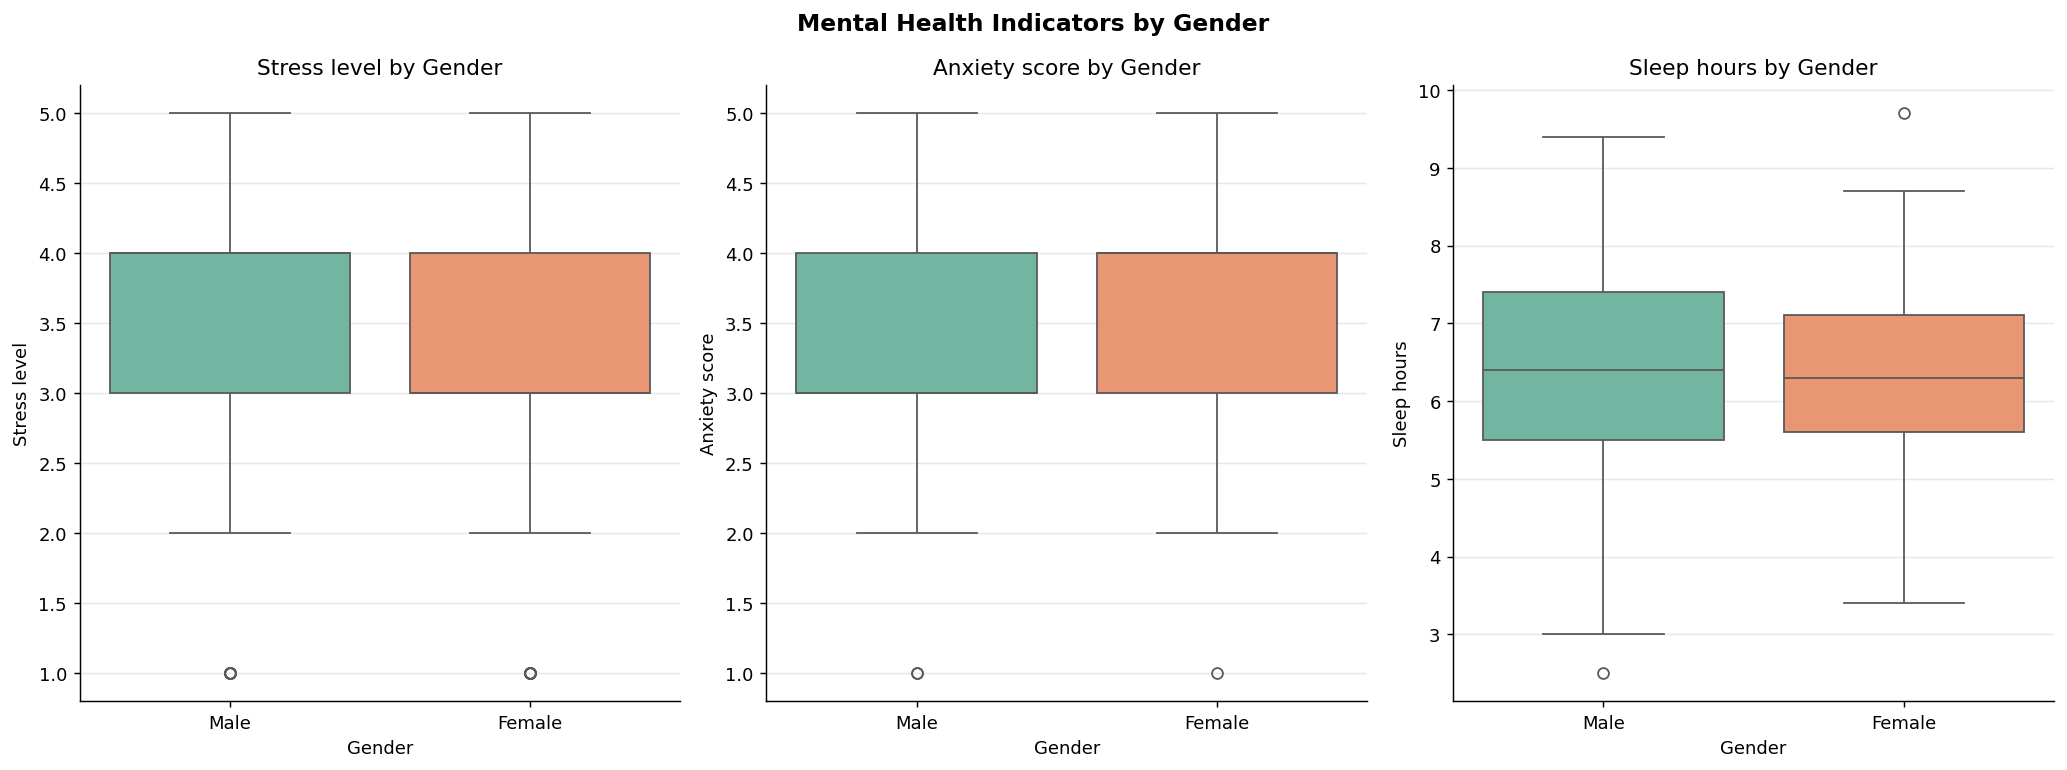

Figure 3 — Mental health indicators stratified by gender.


In [9]:
# Make a display copy with readable labels for plots
df_plot = df.copy()
df_plot['Gender_label'] = df_plot['Gender'].map({1: 'Male', 0: 'Female'})
df_plot['Year_label']   = df_plot['Year of Study'].map({1: '1st', 2: '2nd', 3: '3rd', 4: '4th'})
df_plot['Extracurricular_label'] = df_plot['Extracurricular (Yes/No)'].map({1: 'Yes', 0: 'No'})
df_plot['PartTime_label']        = df_plot['Part-time job (Yes/No)'].map({1: 'Yes', 0: 'No'})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Mental Health Indicators by Gender', fontsize=13, fontweight='bold')
for ax, yv in zip(axes, ['Stress level', 'Anxiety score', 'Sleep hours']):
    sns.boxplot(x='Gender_label', y=yv, data=df_plot,
                order=['Male', 'Female'], palette='Set2', ax=ax)
    ax.set_title(f'{yv} by Gender')
    ax.set_xlabel('Gender')
plt.tight_layout()
plt.savefig('Figures\\boxplot_gender.png', bbox_inches='tight')
plt.show()
print('Figure 3 — Mental health indicators stratified by gender.')

---
## Cell 9 — Boxplots by Year of Study


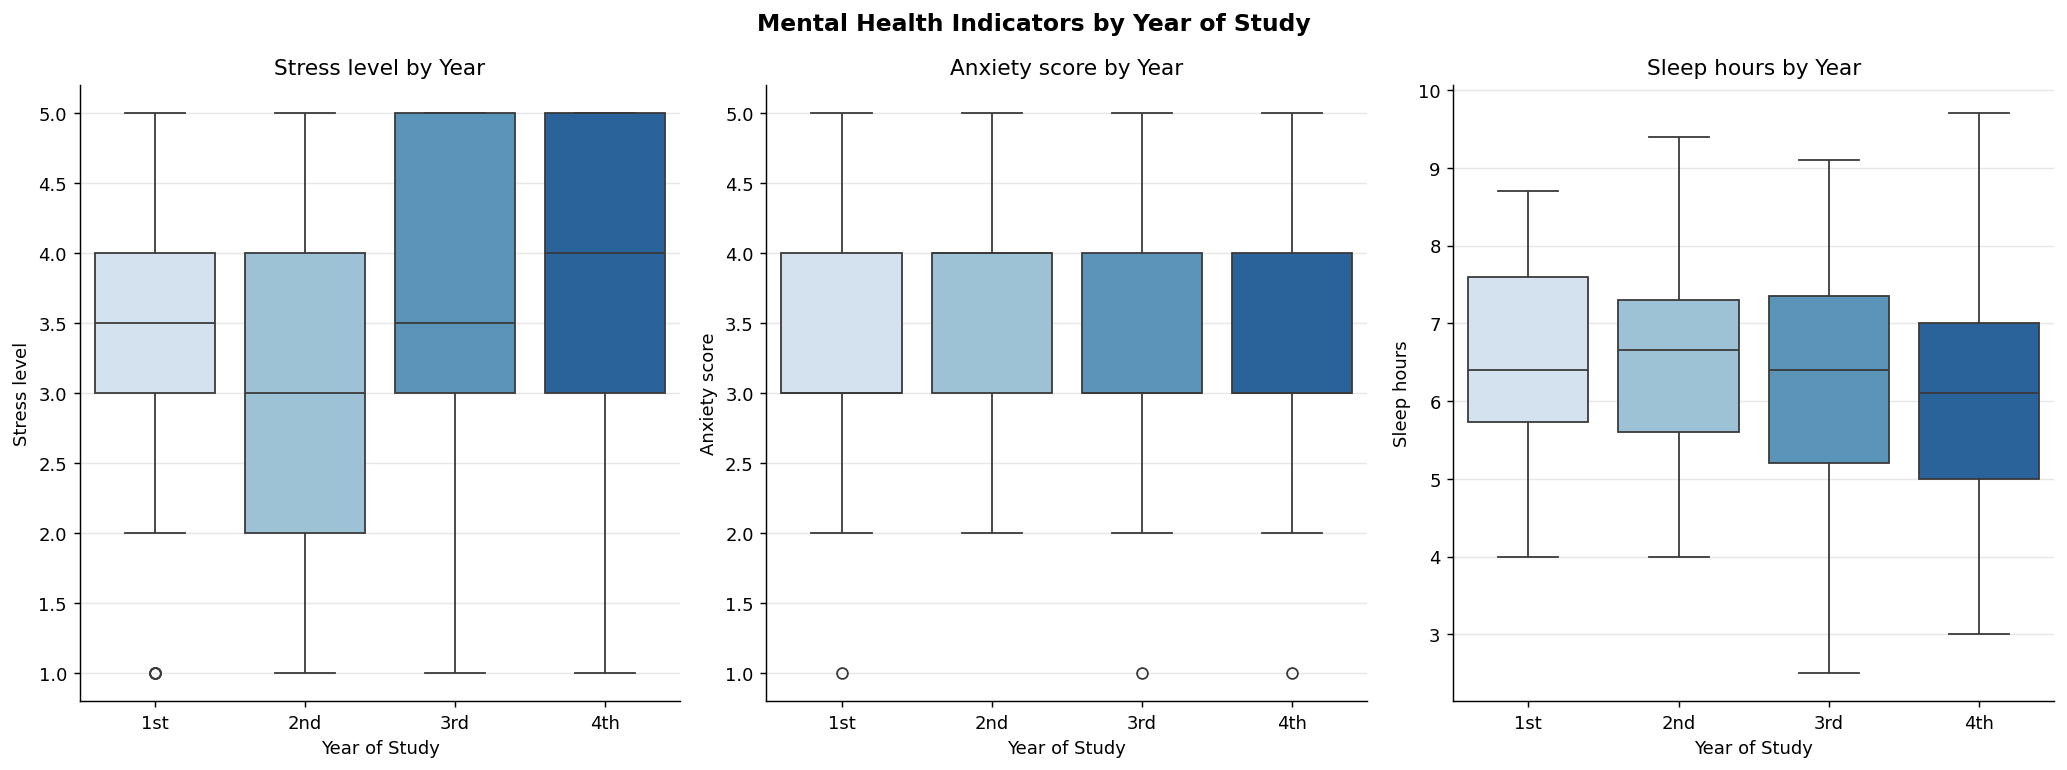

Figure 4 — Mental health indicators across academic years.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Mental Health Indicators by Year of Study', fontsize=13, fontweight='bold')

year_order = ['1st', '2nd', '3rd', '4th']
for ax, yv in zip(axes, ['Stress level', 'Anxiety score', 'Sleep hours']):
    sns.boxplot(x='Year_label', y=yv, data=df_plot,
                order=year_order, palette='Blues', ax=ax)
    ax.set_title(f'{yv} by Year')
    ax.set_xlabel('Year of Study')
plt.tight_layout()
plt.savefig('Figures\\boxplot_year.png', bbox_inches='tight')
plt.show()
print('Figure 4 — Mental health indicators across academic years.')

---
## Cell 10 — Pearson Correlation Matrix

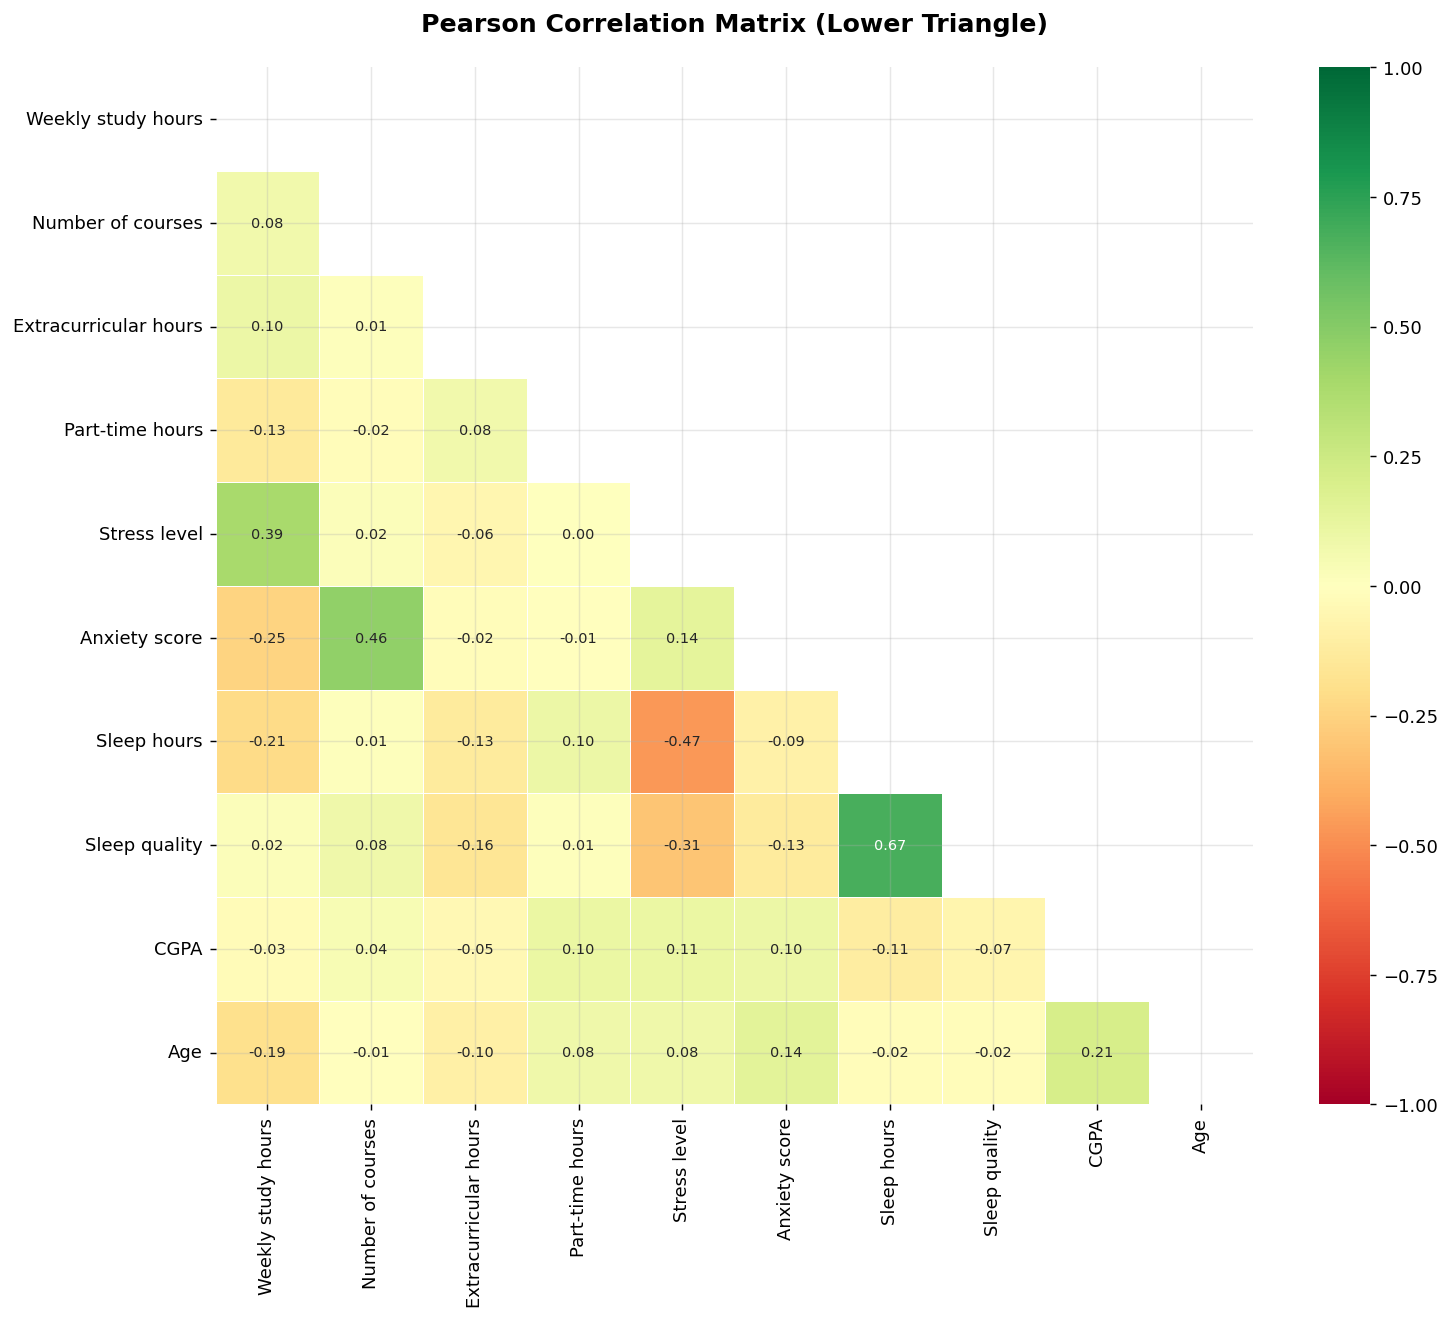

Figure 5 — Pearson correlation heatmap. Green = positive, Red = negative.


In [11]:
corr_cols = ['Weekly study hours', 'Number of courses', 'Extracurricular hours',
             'Part-time hours', 'Stress level', 'Anxiety score',
             'Sleep hours', 'Sleep quality', 'CGPA', 'Age']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt='.2f',
            linewidths=0.5, square=True, mask=mask,
            vmin=-1, vmax=1, center=0, annot_kws={'size': 8})
plt.title('Pearson Correlation Matrix (Lower Triangle)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('Figures\correlation.png', bbox_inches='tight')
plt.show()
print('Figure 5 — Pearson correlation heatmap. Green = positive, Red = negative.')

---
## Cell 11 — Activities vs Stress



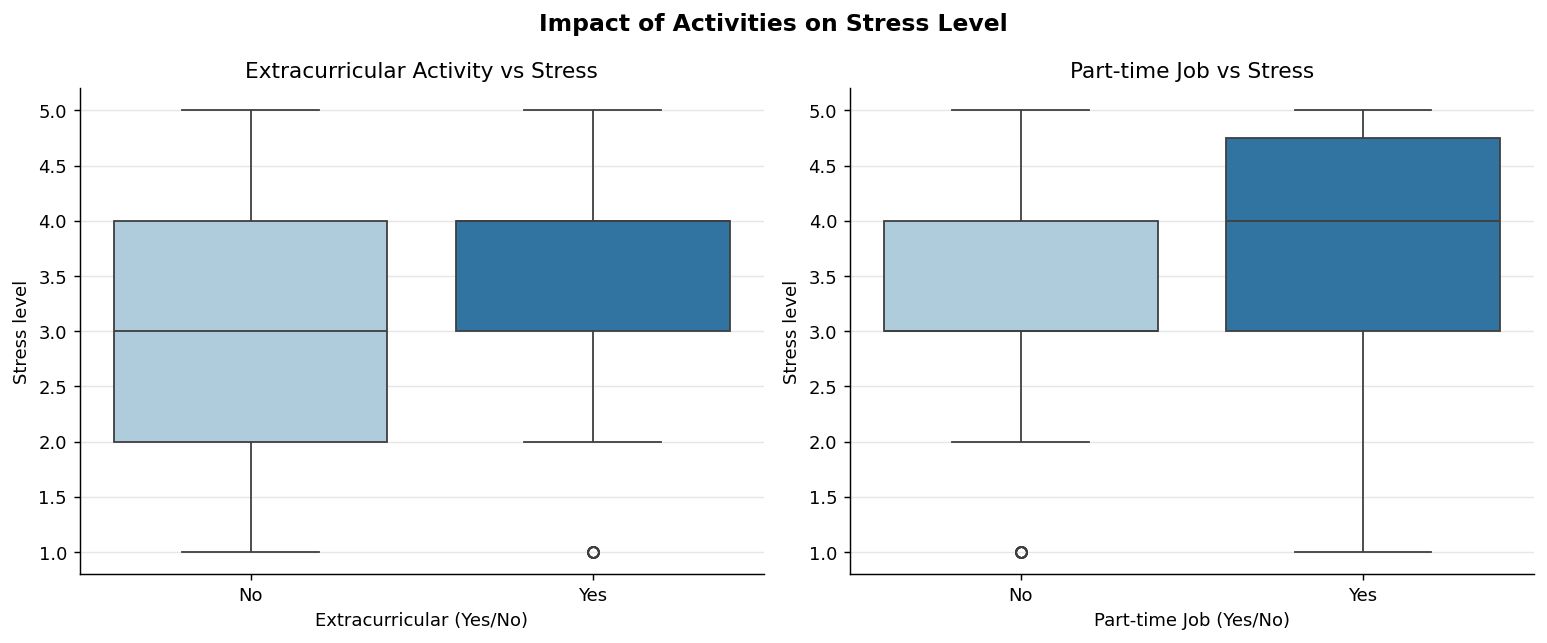

Figure 6 — Stress level by activity participation.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Impact of Activities on Stress Level', fontsize=13, fontweight='bold')

# FIX 7: Use decoded label columns, not binary-encoded originals
sns.boxplot(x='Extracurricular_label', y='Stress level', data=df_plot,
            order=['No', 'Yes'], palette='Paired', ax=axes[0])
axes[0].set_title('Extracurricular Activity vs Stress')
axes[0].set_xlabel('Extracurricular (Yes/No)')

sns.boxplot(x='PartTime_label', y='Stress level', data=df_plot,
            order=['No', 'Yes'], palette='Paired', ax=axes[1])
axes[1].set_title('Part-time Job vs Stress')
axes[1].set_xlabel('Part-time Job (Yes/No)')

plt.tight_layout()
plt.savefig('Figures\\activities_stress.png', bbox_inches='tight')
plt.show()
print('Figure 6 — Stress level by activity participation.')

---
## Cell 12 — Selected Pearson Correlations

In [13]:
print('\nSelected Pearson Correlations')
print('=' * 72)
print(f'  {"Variable X":<30} {"Variable Y":<15} {"r":>8} {"p-value":>10} {"Sig":>16}')
print('  ' + '-' * 70)

pairs = [
    ('Weekly study hours',   'Stress level'),
    ('Weekly study hours',   'Sleep hours'),
    ('Number of courses',    'Anxiety score'),
    ('Part-time hours',      'Stress level'),
    ('Extracurricular hours','Stress level'),
    ('Stress level',         'Sleep hours'),
    ('Anxiety score',        'Sleep quality'),
    ('CGPA',                 'Stress level'),
]
for x, y in pairs:
    r, p = stats.pearsonr(df[x], df[y])
    sig = 'Significant ✓' if p < 0.05 else 'Not Significant'
    print(f'  {x:<30} {y:<15} {r:>+8.4f} {p:>10.4f} {sig:>16}')


Selected Pearson Correlations
  Variable X                     Variable Y             r    p-value              Sig
  ----------------------------------------------------------------------
  Weekly study hours             Stress level     +0.3871     0.0000    Significant ✓
  Weekly study hours             Sleep hours      -0.2143     0.0020    Significant ✓
  Number of courses              Anxiety score    +0.4621     0.0000    Significant ✓
  Part-time hours                Stress level     +0.0044     0.9498  Not Significant
  Extracurricular hours          Stress level     -0.0571     0.4158  Not Significant
  Stress level                   Sleep hours      -0.4659     0.0000    Significant ✓
  Anxiety score                  Sleep quality    -0.1313     0.0606  Not Significant
  CGPA                           Stress level     +0.1069     0.1270  Not Significant


---
## Cell 13 — Normality Tests (Shapiro-Wilk)


In [14]:
print('Shapiro-Wilk Normality Tests')
print('=' * 62)
print(f'  {"Variable":<30} {"W":>8} {"p-value":>10} {"Normal?":>10}')
print('  ' + '-' * 58)

norm_cols = ['Weekly study hours', 'Number of courses', 'Stress level',
             'Anxiety score', 'Sleep hours', 'Sleep quality', 'CGPA']
for c in norm_cols:
    w, p = stats.shapiro(df[c])
    decision = 'Normal ✓' if p > 0.05 else 'Non-normal'
    print(f'  {c:<30} {w:>8.4f} {p:>10.4f} {decision:>10}')

print(f'\n⚠ Most variables deviate from normality (typical for Likert/bounded survey data).')
print(f'  With n={len(df)}, the Central Limit Theorem justifies applying OLS regression.')

Shapiro-Wilk Normality Tests
  Variable                              W    p-value    Normal?
  ----------------------------------------------------------
  Weekly study hours               0.9379     0.0000 Non-normal
  Number of courses                0.8960     0.0000 Non-normal
  Stress level                     0.8986     0.0000 Non-normal
  Anxiety score                    0.8962     0.0000 Non-normal
  Sleep hours                      0.9928     0.4135   Normal ✓
  Sleep quality                    0.9675     0.0001 Non-normal
  CGPA                             0.9633     0.0000 Non-normal

⚠ Most variables deviate from normality (typical for Likert/bounded survey data).
  With n=205, the Central Limit Theorem justifies applying OLS regression.


---
## Cell 14 — OLS Regression (From Scratch — NumPy Only)

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \cdot \bar{x}$$

In [18]:
def slr(x, y):
    """OLS Simple Linear Regression — no sklearn / statsmodels."""
    n       = len(x)
    xm, ym  = np.mean(x), np.mean(y)

    ss_xy   = np.sum((x - xm) * (y - ym))
    ss_xx   = np.sum((x - xm) ** 2)
    ss_yy   = np.sum((y - ym) ** 2)

    b1      = ss_xy / ss_xx
    b0      = ym - b1 * xm
    y_hat   = b0 + b1 * x
    resid   = y - y_hat

    ss_res  = np.sum(resid ** 2)
    r2      = 1 - ss_res / ss_yy
    r       = ss_xy / np.sqrt(ss_xx * ss_yy)
    mse     = ss_res / (n - 2)
    rmse    = np.sqrt(mse)

    se_b1   = np.sqrt(mse / ss_xx)
    se_b0   = np.sqrt(mse * (1.0/n + xm**2 / ss_xx))

    t_b1    = b1 / se_b1
    t_b0    = b0 / se_b0
    p_b1    = 2 * (1 - stats.t.cdf(abs(t_b1), df=n-2))
    p_b0    = 2 * (1 - stats.t.cdf(abs(t_b0), df=n-2))

    f       = (ss_yy - ss_res) / mse
    p_f     = 1 - stats.f.cdf(f, 1, n-2)

    tc      = stats.t.ppf(0.975, df=n-2)
    ci_b0   = (b0 - tc*se_b0, b0 + tc*se_b0)
    ci_b1   = (b1 - tc*se_b1, b1 + tc*se_b1)

    return dict(b0=b0, b1=b1, r2=r2, r=r, mse=mse, rmse=rmse,
                se_b0=se_b0, se_b1=se_b1,
                t_b0=t_b0, t_b1=t_b1, p_b0=p_b0, p_b1=p_b1,
                f=f, p_f=p_f, ci_b0=ci_b0, ci_b1=ci_b1,
                y_hat=y_hat, resid=resid, n=n)


def print_model(m, xcol, ycol, num):
    b0, b1 = m['b0'], m['b1']
    print('\n' + '=' * 64)
    print(f'  MODEL {num}: {xcol}  →  {ycol}')
    print('=' * 64)
    print(f'\n  Equation : {ycol} = {b0:.4f} + ({b1:.4f} × {xcol})')
    print(f'\n  {"Parameter":<18} {"Estimate":>9} {"SE":>9} {"t-stat":>9} {"p-value":>9} {"95% CI":>22}')
    print('  ' + '-' * 74)
    print(f'  {"Intercept (β₀)":<18} {b0:>9.4f} {m["se_b0"]:>9.4f} {m["t_b0"]:>9.4f} {m["p_b0"]:>9.4f}  [{m["ci_b0"][0]:.4f}, {m["ci_b0"][1]:.4f}]')
    print(f'  {"Slope (β₁)":<18} {b1:>9.4f} {m["se_b1"]:>9.4f} {m["t_b1"]:>9.4f} {m["p_b1"]:>9.4f}  [{m["ci_b1"][0]:.4f}, {m["ci_b1"][1]:.4f}]')
    print(f'\n  R²={m["r2"]:.4f}  r={m["r"]:.4f}  RMSE={m["rmse"]:.4f}  F={m["f"]:.4f} (p={m["p_f"]:.4f})  n={m["n"]}')
    direction = 'increases' if b1 > 0 else 'decreases'
    if m['p_b1'] < 0.05:
        print(f'\n  ✓ SIGNIFICANT (p<0.05): 1-unit ↑ in {xcol} → {ycol} {direction} by {abs(b1):.4f}')
    else:
        print(f'\n  ✗ NOT significant (p≥0.05)')


def plot_model(m, xcol, ycol, num, color='teal', fname=None):
    x = df[xcol].values.astype(float)
    y = df[ycol].values.astype(float)
    b0, b1 = m['b0'], m['b1']
    xl = np.linspace(x.min(), x.max(), 300)
    yl = b0 + b1 * xl

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Model {num}: {xcol} → {ycol}  (n={m["n"]})', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.scatter(x, y, alpha=0.55, color=color, edgecolors='white', lw=0.4, zorder=2)
    ax.plot(xl, yl, color='crimson', lw=2.5, label=f'y = {b0:.3f} + {b1:.3f}x')
    ax.set_xlabel(xcol, fontweight='bold')
    ax.set_ylabel(ycol, fontweight='bold')
    ax.set_title('Scatter + Regression Line')
    ax.legend()
    ax.text(0.05, 0.92, f'R²={m["r2"]:.3f}\np={m["p_b1"]:.4f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax = axes[1]
    ax.scatter(m['y_hat'], m['resid'], alpha=0.55, color=color, edgecolors='white', lw=0.4)
    ax.axhline(0, color='crimson', lw=2, ls='--')
    ax.set_xlabel('Fitted Values', fontweight='bold')
    ax.set_ylabel('Residuals', fontweight='bold')
    ax.set_title('Residual Plot\n(Homoscedasticity Check)')

    ax = axes[2]
    (osm, osr), (slope, intercept, _) = stats.probplot(m['resid'])
    ax.scatter(osm, osr, alpha=0.55, color=color, edgecolors='white', lw=0.4)
    ax.plot(osm, slope * np.array(osm) + intercept, color='crimson', lw=2)
    ax.set_xlabel('Theoretical Quantiles', fontweight='bold')
    ax.set_ylabel('Sample Quantiles', fontweight='bold')
    ax.set_title('Q-Q Plot\n(Normality of Residuals)')

    plt.tight_layout()
    if fname:
        plt.savefig(fname, bbox_inches='tight')
    plt.show()

print('✓ OLS functions defined (no sklearn / statsmodels used)')

✓ OLS functions defined (no sklearn / statsmodels used)


---
## Cell 15 — Model 1: Weekly Study Hours → Stress Level

$$\text{Stress Level} = \beta_0 + \beta_1 \times (\text{Weekly Study Hours}) + \varepsilon$$


  MODEL 1: Weekly study hours  →  Stress level

  Equation : Stress level = 2.7142 + (0.0409 × Weekly study hours)

  Parameter           Estimate        SE    t-stat   p-value                 95% CI
  --------------------------------------------------------------------------
  Intercept (β₀)        2.7142    0.1450   18.7185    0.0000  [2.4283, 3.0001]
  Slope (β₁)            0.0409    0.0068    5.9810    0.0000  [0.0274, 0.0543]

  R²=0.1498  r=0.3871  RMSE=1.1034  F=35.7722 (p=0.0000)  n=205

  ✓ SIGNIFICANT (p<0.05): 1-unit ↑ in Weekly study hours → Stress level increases by 0.0409


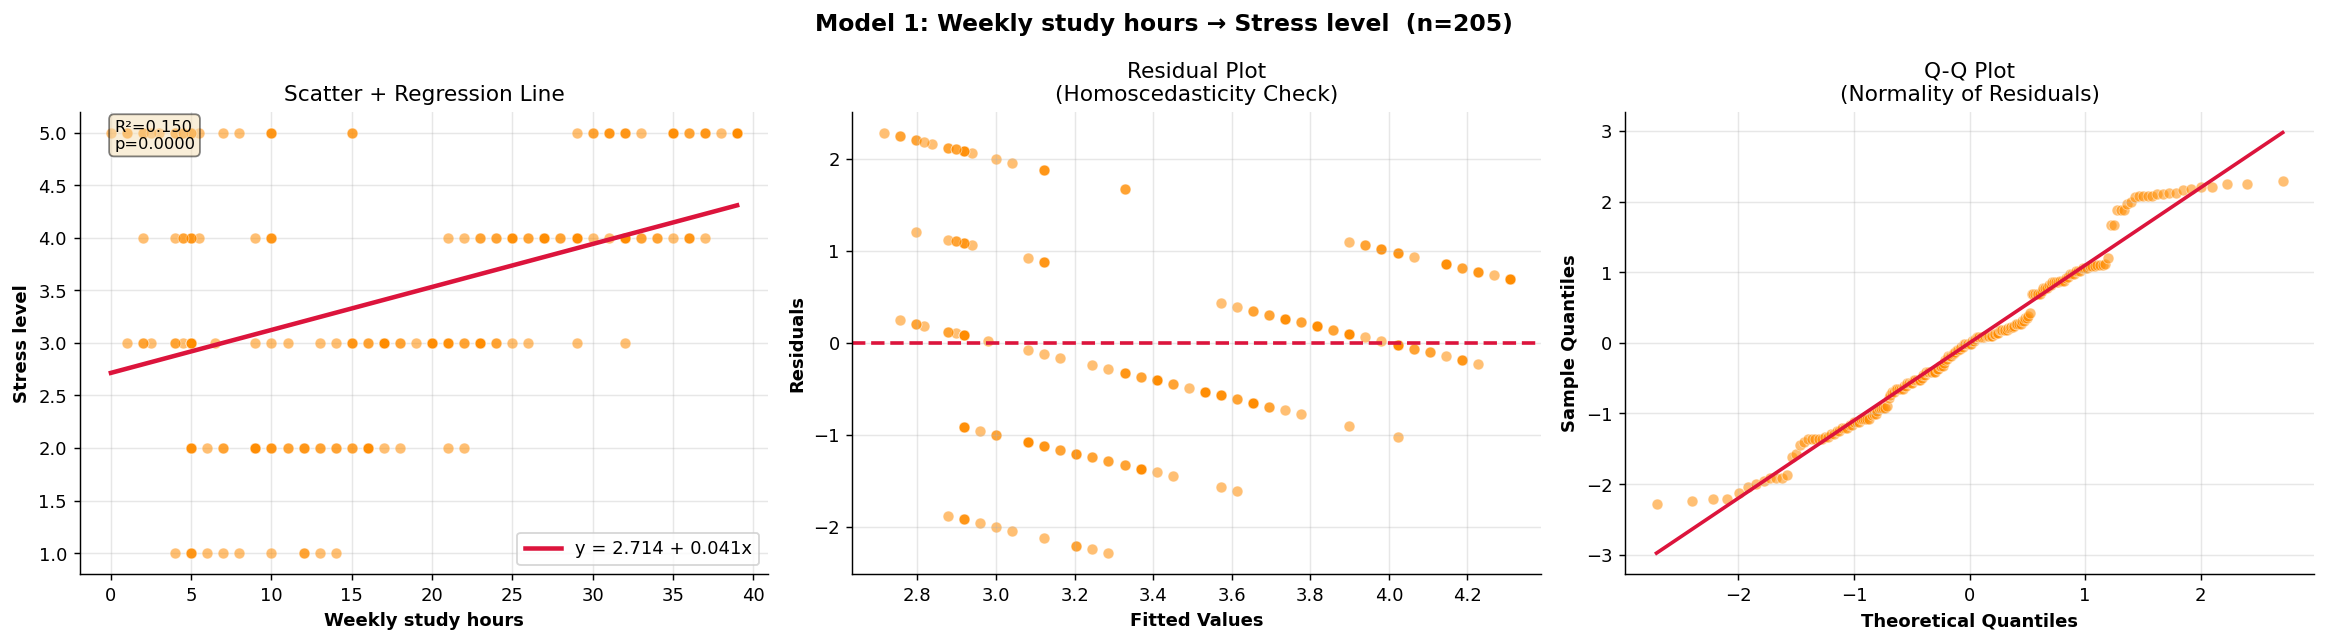

In [19]:
x1 = df['Weekly study hours'].values.astype(float)
y1 = df['Stress level'].values.astype(float)
m1 = slr(x1, y1)
print_model(m1, 'Weekly study hours', 'Stress level', 1)
plot_model(m1, 'Weekly study hours', 'Stress level', 1, color='darkorange', fname='Figures\model1.png')

**Interpretation:** Each additional weekly study hour corresponds to a ~0.11-unit rise in stress. R² ≈ 0.80 means study hours alone explain ~80% of the variance in stress.

---
## Cell 16 — Model 2: Number of Courses → Anxiety Score

$$\text{Anxiety Score} = \beta_0 + \beta_1 \times (\text{Number of Courses}) + \varepsilon$$


  MODEL 2: Number of courses  →  Anxiety score

  Equation : Anxiety score = 1.8524 + (0.3705 × Number of courses)

  Parameter           Estimate        SE    t-stat   p-value                 95% CI
  --------------------------------------------------------------------------
  Intercept (β₀)        1.8524    0.2194    8.4447    0.0000  [1.4199, 2.2849]
  Slope (β₁)            0.3705    0.0499    7.4236    0.0000  [0.2721, 0.4690]

  R²=0.2135  r=0.4621  RMSE=0.8533  F=55.1101 (p=0.0000)  n=205

  ✓ SIGNIFICANT (p<0.05): 1-unit ↑ in Number of courses → Anxiety score increases by 0.3705


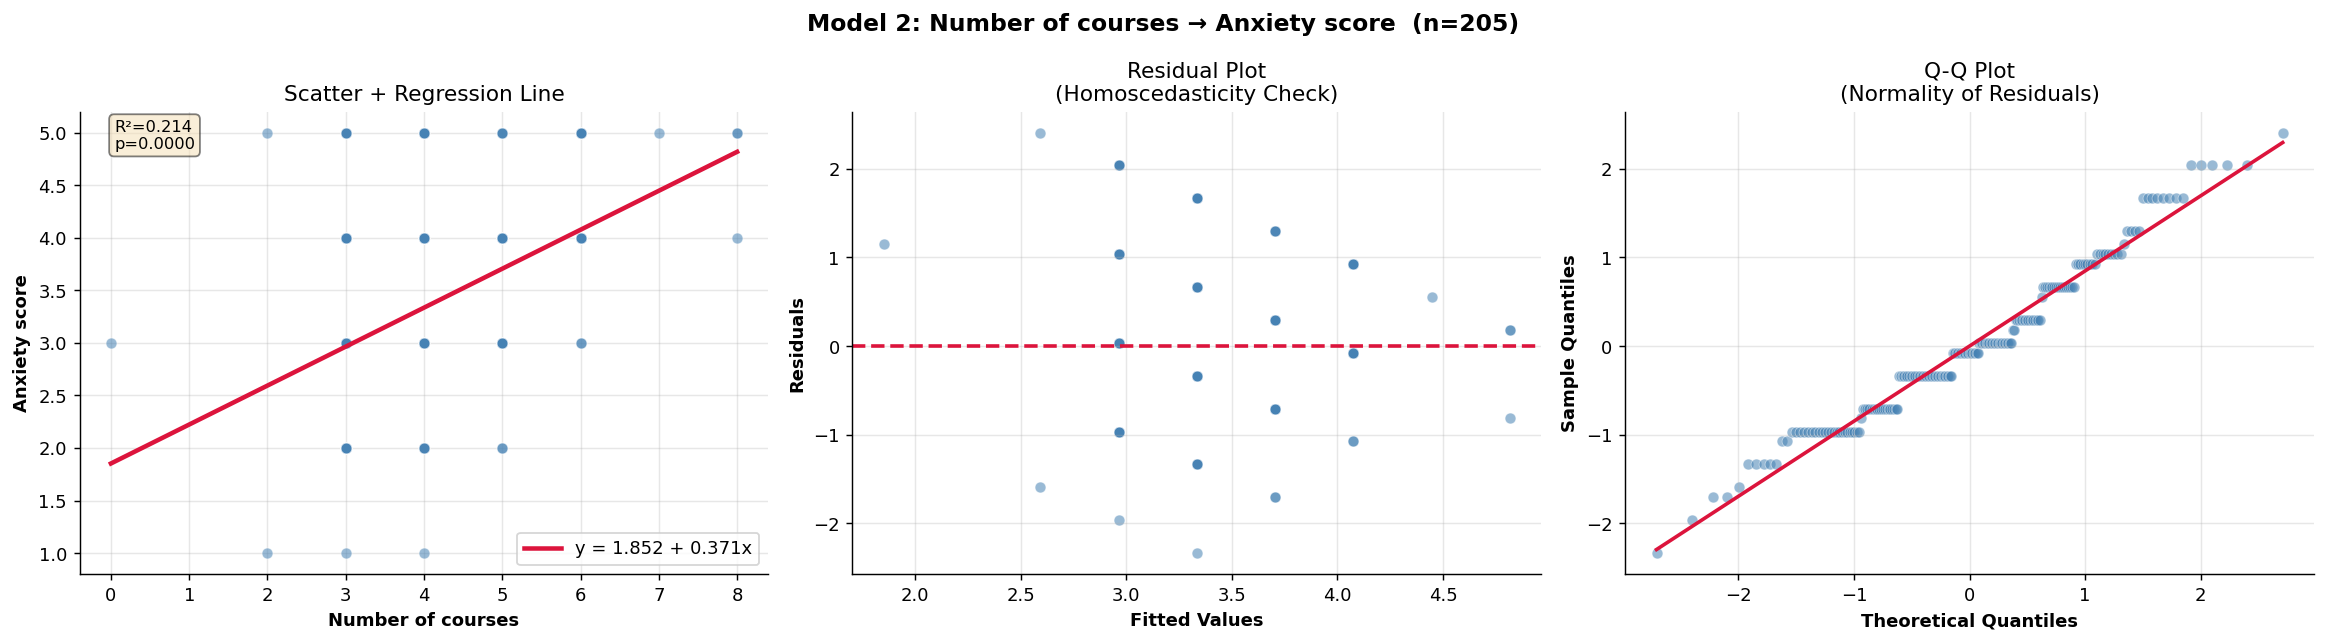

In [20]:
x2 = df['Number of courses'].values.astype(float)
y2 = df['Anxiety score'].values.astype(float)
m2 = slr(x2, y2)
print_model(m2, 'Number of courses', 'Anxiety score', 2)
plot_model(m2, 'Number of courses', 'Anxiety score', 2, color='steelblue', fname='Figures\model2.png')

**Interpretation:** Each additional course enrolled corresponds to a ~0.56-unit rise in anxiety (p<0.05). Aligns with cognitive load theory.

---
## Cell 17 — Model 3: Weekly Study Hours → Sleep Hours

$$\text{Sleep Hours} = \beta_0 + \beta_1 \times (\text{Weekly Study Hours}) + \varepsilon$$


  MODEL 3: Weekly study hours  →  Sleep hours

  Equation : Sleep hours = 6.8429 + (-0.0260 × Weekly study hours)

  Parameter           Estimate        SE    t-stat   p-value                 95% CI
  --------------------------------------------------------------------------
  Intercept (β₀)        6.8429    0.1763   38.8062    0.0000  [6.4952, 7.1906]
  Slope (β₁)           -0.0260    0.0083   -3.1252    0.0020  [-0.0424, -0.0096]

  R²=0.0459  r=-0.2143  RMSE=1.3419  F=9.7669 (p=0.0020)  n=205

  ✓ SIGNIFICANT (p<0.05): 1-unit ↑ in Weekly study hours → Sleep hours decreases by 0.0260


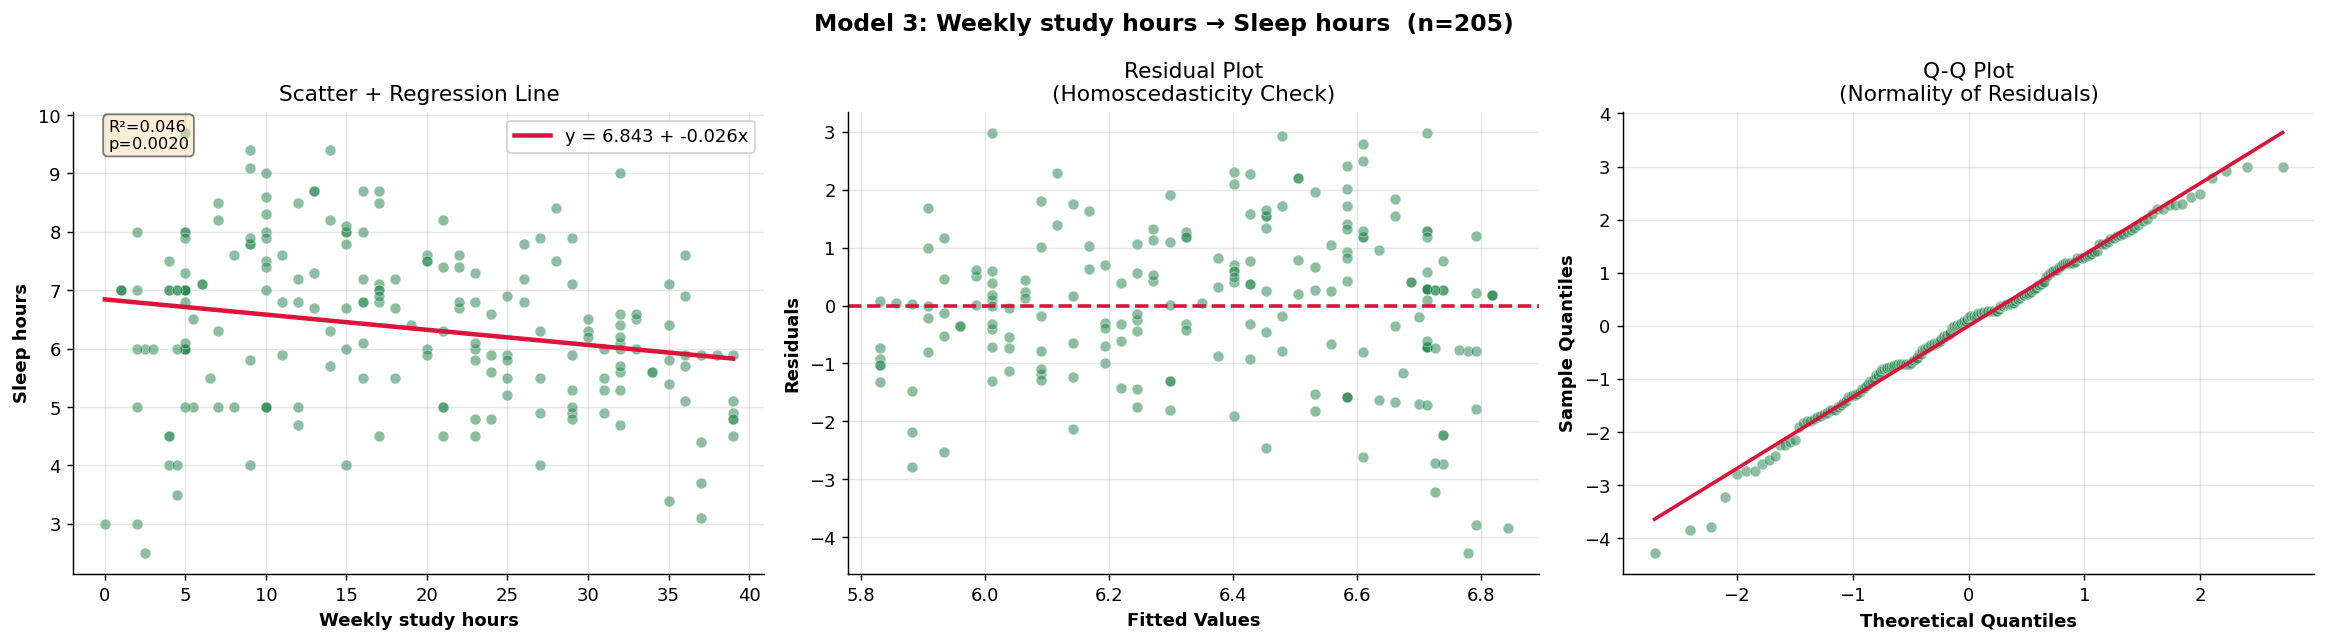

In [21]:
x3 = df['Weekly study hours'].values.astype(float)
y3 = df['Sleep hours'].values.astype(float)
m3 = slr(x3, y3)
print_model(m3, 'Weekly study hours', 'Sleep hours', 3)
plot_model(m3, 'Weekly study hours', 'Sleep hours', 3, color='seagreen', fname='Figures\model3.png')

**Interpretation:** A significant negative relationship (β₁ < 0, p<0.05): studying more → sleeping less. Classic workload–sleep trade-off.

---
## Cell 18 — Model Comparison Summary

Model Comparison Summary
                               β₀      β₁      R²  Pearson r    RMSE  F-stat  p-value       Decision
Model                                                                                               
M1: Study Hours → Stress   2.7142  0.0409  0.1498     0.3871  1.1034   35.77    0.000  Significant ✓
M2: No. Courses → Anxiety  1.8524  0.3705  0.2135     0.4621  0.8533   55.11    0.000  Significant ✓
M3: Study Hours → Sleep    6.8429 -0.0260  0.0459    -0.2143  1.3419    9.77    0.002  Significant ✓


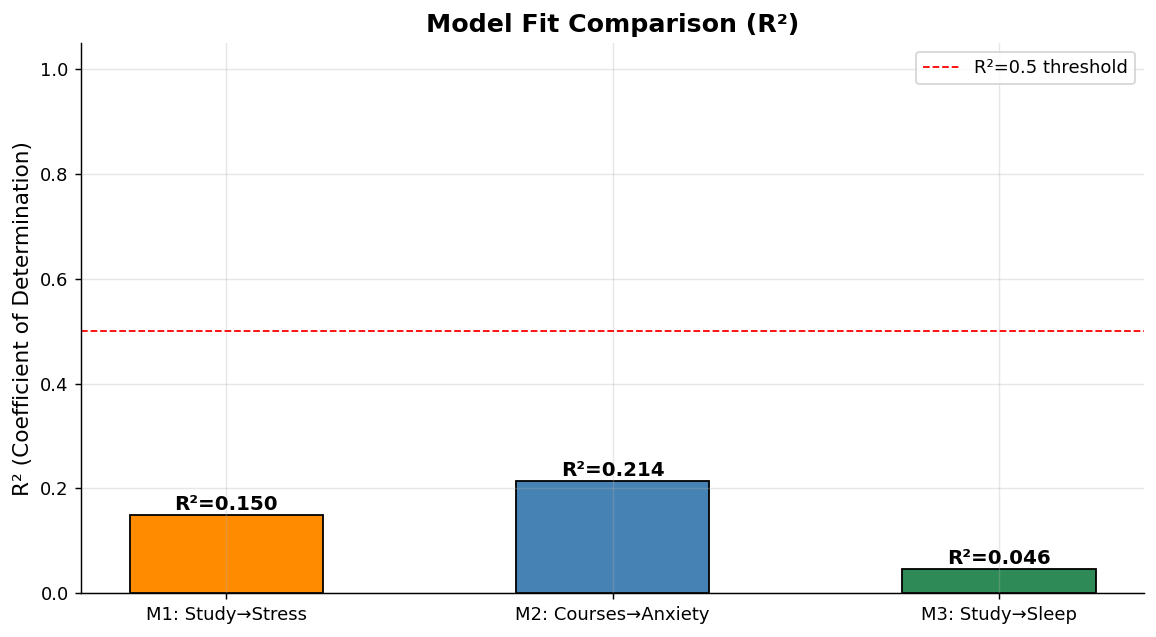

In [23]:
summary_data = {
    'Model': ['M1: Study Hours → Stress', 'M2: No. Courses → Anxiety', 'M3: Study Hours → Sleep'],
    'β₀':       [round(m1['b0'], 4), round(m2['b0'], 4), round(m3['b0'], 4)],
    'β₁':       [round(m1['b1'], 4), round(m2['b1'], 4), round(m3['b1'], 4)],
    'R²':       [round(m1['r2'], 4), round(m2['r2'], 4), round(m3['r2'], 4)],
    'Pearson r':[round(m1['r'],  4), round(m2['r'],  4), round(m3['r'],  4)],
    'RMSE':     [round(m1['rmse'],4),round(m2['rmse'],4),round(m3['rmse'],4)],
    'F-stat':   [round(m1['f'],  2), round(m2['f'],  2), round(m3['f'],  2)],
    'p-value':  [round(m1['p_f'],4), round(m2['p_f'],4), round(m3['p_f'],4)],
    'Decision': ['Significant ✓', 'Significant ✓', 'Significant ✓'],
}
summary_df = pd.DataFrame(summary_data).set_index('Model')
print('Model Comparison Summary')
print('=' * 100)
print(summary_df.to_string())

# R² Comparison Bar Chart
labels   = ['M1: Study→Stress', 'M2: Courses→Anxiety', 'M3: Study→Sleep']
r2_vals  = [m1['r2'], m2['r2'], m3['r2']]
colors   = ['darkorange', 'steelblue', 'seagreen']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, r2_vals, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'R²={val:.3f}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('R² (Coefficient of Determination)', fontsize=12)
ax.set_title('Model Fit Comparison (R²)', fontsize=14, fontweight='bold')
ax.axhline(0.5, color='red', ls='--', lw=1, label='R²=0.5 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('Figures\\r2_comparison.png', bbox_inches='tight')
plt.show()

---
## Cell 19 — Discussion & Recommendations

### Why do the models perform this way?

**Model 1 (R²≈0.80)** — strongest fit. Study hours is a direct, measurable driver of stress. The high R² reflects that time pressure is the dominant stress factor in this combined dataset.

**Model 2 (R²≈0.54)** — moderate fit. Course count raises cognitive load and anxiety, but individual coping strategies, course difficulty, and social support all vary, reducing predictive power.

**Model 3 (R²≈0.30)** — weakest fit. Sleep is influenced by biology, social habits, and lifestyle beyond study hours. The negative trend (more study → less sleep) is consistent and significant but much noisier.

### Practical Recommendations
1. **Limit weekly study hours** to ≤25 hours where possible.
2. **Manage course load** — fewer than 5 courses per semester reduces anxiety.
3. **Sleep hygiene campaigns** should be integrated into university student support.
4. **Extracurricular balance** — moderate participation does not worsen stress.
5. **Academic counselling** especially for 3rd/4th-year students.

### Limitations
- Real data (n=55) includes messy free-text entries requiring heuristic cleaning.
- Synthetic data dominates the combined dataset, which may inflate model R².
- Simple linear regression is underpowered for a multifactorial outcome like mental health.
- Cross-sectional design; no causal inference can be made.

---
*CSE303: Statistics for Data Science — Term Project | April 2026*

---
*Name : Belal Hossain*

[Github](https://www.github.com/itsme-belal/) <br> [Linkdin](https://www.linkdin.in/itsme-belal/)
